In [31]:
#setup notebook
%load_ext autoreload
%autoreload 2
%matplotlib inline
import logging
logging.basicConfig(format='%(asctime)s %(levelname)s:%(message)s', level=logging.INFO, datefmt='%I:%M:%S')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
from sdata.sclass import spec_to_class
spec_to_class("Material", on_error="ignore")

sdata.base.Base

In [51]:
from sdata.base import sclass_factory, sdata_factory, cls_from_spec

material = cls_from_spec("Material", on_error="ignore")
tensiontest = cls_from_spec("TensionTest", on_error="ignore")

In [95]:
from sdata.base import sclass_factory, sdata_factory

m = sclass_factory("Material", on_error="ignore")
m.__class__.__name__

'Material'

In [67]:

from sdata.sclass.process import create_process_class, create_composite_process_class, ProcessData, ProcessNode, CompositeProcess


class DataClass_1(ProcessData):
    default_attributes = [
        {"name": "var_a", "value": None, "dtype": "float", "description": "Variable A", "required": True},
        {"name": "var_b", "value": None, "dtype": "float", "description": "Variable B", "required": True},
    ]

class DataClass_2(ProcessData):
    default_attributes = [
        {"name": "var_c", "value": None, "dtype": "float", "description": "Variable C", "required": True},
    ]

class DataClass_3(ProcessData):
    default_attributes = [
        {"name": "var_d", "value": None, "dtype": "float", "description": "Variable D", "required": True},
    ]

class DataClass_4(ProcessData):
    default_attributes = [
        {"name": "var_e", "value": None, "dtype": "float", "description": "Variable E", "required": True},
    ]

class DataClass_5(ProcessData):
    default_attributes = [
        {"name": "var_e", "value": None, "dtype": "float", "description": "Variable E", "required": True},
    ]

class DataClass_6(ProcessData):
    default_attributes = [
        {"name": "var_e", "value": None, "dtype": "float", "description": "Variable E", "required": True},
    ]

class DataClass_7(ProcessData):
    default_attributes = [
        {"name": "var_e", "value": None, "dtype": "float", "description": "Variable E", "required": True},
    ]



In [54]:
Process_1_Generic = create_process_class(
    'Process_1',
    input_classes={'DataClass_1': DataClass_1, 'DataClass_2': DataClass_2, "a": tensiontest},
    output_classes={'DataClass_3': DataClass_3, 'DataClass_6': DataClass_6},
)
Process_1_Generic

sdata.sclass.process.Process_1

In [70]:
Process_2_Generic = create_process_class(
    'Process_3',
    input_classes={'DataClass_1': DataClass_1, 'DataClass_3': DataClass_3, 'DataClass_5': DataClass_5, "Material1": m.__class__},
    output_classes={'DataClass_4': DataClass_4},
)
Process_2_Generic

sdata.sclass.process.Process_3

In [71]:
Process_3_Generic = create_process_class(
    'Process_2',
    input_classes={"Material1": m.__class__},
    output_classes={'DataClass_7': DataClass_7},
)
Process_2_Generic

sdata.sclass.process.Process_3

In [63]:
Process_1_plus_2_Generic = create_composite_process_class(
    "Process_1_plus_2",
    [Process_1_Generic, Process_2_Generic]
)
Process_1_plus_2_Generic

sdata.sclass.process.create_composite_process_class.<locals>.GenericComposite

In [60]:
from typing import Dict, Type, List, Union
class Process_1_plus_2(CompositeProcess):
    def __init__(self, inputs: Dict[str, ProcessData] = None, **kwargs):
        super().__init__(name="Process_1+2", processes=[Process_1_Generic, Process_2_Generic], inputs=inputs, **kwargs)
composite = Process_1_plus_2()
composite

<Process_1_plus_2@process_1_2@555db11a16d7403eb80cd8355379d18d>

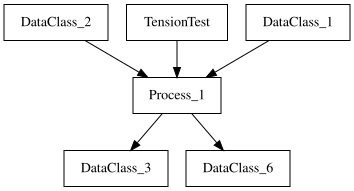

In [57]:
from sdata.sclass.process_graph import ProcessGraph
from IPython.display import display, SVG

g = ProcessGraph()
g.add_process(Process_1_Generic)
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)

display(SVG(dot_graph.pipe(format='svg')))

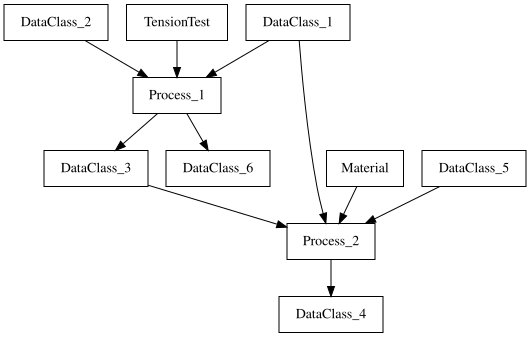

In [58]:
g = ProcessGraph()
g.add_process(Process_1_Generic)
g.add_process(Process_2_Generic)
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)

display(SVG(dot_graph.pipe(format='svg')))

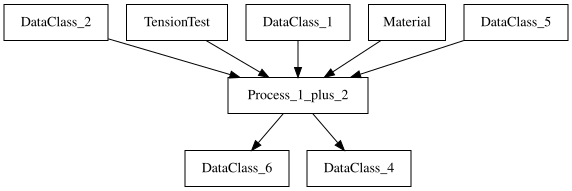

In [59]:
from sdata.sclass.process_graph import ProcessGraph
from IPython.display import display, SVG

g = ProcessGraph()
g.add_process(Process_1_plus_2)
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)

display(SVG(dot_graph.pipe(format='svg')))

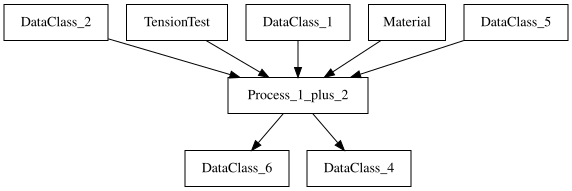

In [94]:
from sdata.sclass.process_graph import ProcessGraph
from IPython.display import display, SVG

g = ProcessGraph()
g.add_process(Process_1_plus_2_Generic)
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)
dot_graph

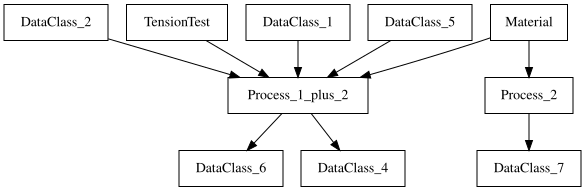

In [74]:
from sdata.sclass.process_graph import ProcessGraph
from IPython.display import display, SVG

g = ProcessGraph()
g.add_process(Process_1_plus_2_Generic)
g.add_process(Process_3_Generic)

dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)

display(SVG(dot_graph.pipe(format='svg')))

In [83]:
Process_1_plus_2().process_classes

[sdata.sclass.process.Process_1, sdata.sclass.process.Process_3]

In [84]:
Process_1_plus_2_Generic().process_classes

[sdata.sclass.process.Process_1, sdata.sclass.process.Process_2]

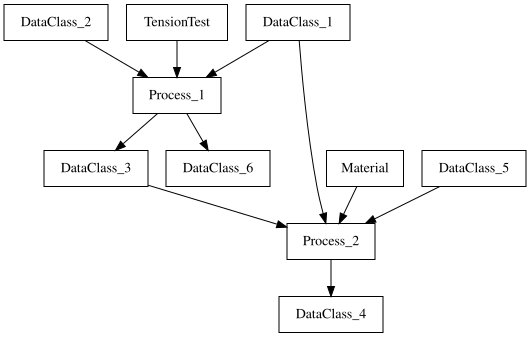

In [86]:
from sdata.sclass.process_graph import ProcessGraph, get_process_graph
from IPython.display import display, SVG

g = ProcessGraph()
for process in Process_1_plus_2_Generic().process_classes:
    g.add_process(process)

dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)

display(SVG(dot_graph.pipe(format='svg')))

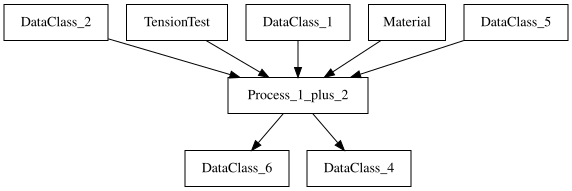

In [93]:
get_process_graph([Process_1_plus_2_Generic])

In [92]:
Process_1_Generic.process_classes

AttributeError: type object 'Process_1' has no attribute 'process_classes'